In [ ]:
import torch
import numpy as np
from resnet_18.graspy_resnet18 import GraSpyResNet18
from zevin_coughlin_net.zevin_coughlin_net import ZevinCoughlinNet
from zevin_coughlin_net.data_preprocessing import preprocessData
from heatmap_algos.GradCAM import GradCAM
from heatmap_algos.HiResCAM import HiResCAM
import warnings
warnings.filterwarnings('ignore')

In [ ]:
num_classes = 22
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_folder = "resnet_18"
weight_name = "best_resnet18.pt"
dataset_path = "./gravity-spy-dataset/"

In [ ]:
training_loader, validation_loader, testing_loader = preprocessData(dataset_path)

if weights_folder == "resnet_18":
    model = GraSpyResNet18(num_classes=num_classes)
elif weights_folder == "ZevinCoughlinNet":
    model = ZevinCoughlinNet(num_classes=num_classes)

model.load_state_dict(
    torch.load(weights_folder + "/" + weight_name , map_location=device)
);

model = model.to(device);
model.eval();

In [4]:
model

GravitySpyResNet18(
  (resnet): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

In [5]:
target_layer = model.resnet.layer4[-1]
target_layer

BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [6]:
gradcam = GradCAM(model, target_layer)
hirescam = HiResCAM(model, target_layer)

inputs, labels = next(iter(validation_loader))
inputs = inputs.to(device)

# Generate CAM
cam = gradcam.generate(inputs[:1], class_idx=labels[0].item())
cam = hirescam.generate(inputs[:1], class_idx=labels[0].item())

# Extract spectrogram image
image = inputs[0, 0].detach().cpu().numpy().astype("float32")

In [7]:
import matplotlib.pyplot as plt

def show_cam(image, cam, alpha=0.5):
    image = image.astype("float32")
    cam = cam.astype("float32")

    assert image.ndim == 2, f"Expected 2D image, got {image.shape}"
    assert cam.ndim == 2, f"Expected 2D CAM, got {cam.shape}"

    plt.figure(figsize=(4,4))
    plt.imshow(image, cmap="gray")
    plt.imshow(cam, cmap="jet", alpha=alpha)
    plt.axis("off")
    
    plt.figure(figsize=(4,4))
    plt.imshow(image, cmap="gray")
    plt.axis("off")

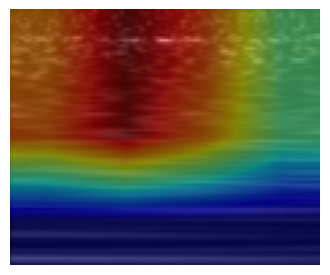

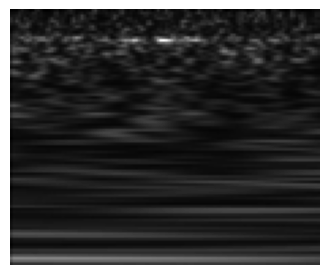

In [8]:
show_cam(image, cam)